# Mejora del modelo — SARIMA vs SARIMAX vs ETS vs Prophet vs LightGBM

Notebook extendido que compara **5 modelos de forecasting** para los productos más relevantes (Pareto 80%):

| Modelo | Tipo | Ventaja clave |
|--------|------|---------------|
| SARIMA | Estadístico | Captura AR + MA + estacionalidad |
| SARIMAX | Estadístico | SARIMA + variables exógenas |
| ETS (Holt-Winters) | Suavizado exp. | Robusto en series cortas |
| Prophet | Descomposición | Tendencia + estacionalidad automática |
| LightGBM + Lags | ML | No lineal, aprovecha variables externas |

El mejor modelo por producto se selecciona minimizando MAPE en las últimas 4 semanas (test).

In [1]:
# =============================================================================
# 0. LIBRERÍAS Y CONFIGURACIÓN
# =============================================================================

import os
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore", ConvergenceWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (12, 5)

RANDOM_STATE = 42
HORIZONTE = 4          # 4 semanas adelante
M = 4                  # patrón estacional mensual aproximado en datos semanales

In [2]:
# =============================================================================
# 1. CARGA DE DATOS
# =============================================================================

# El notebook intenta encontrar el archivo en diferentes nombres comunes.
posibles_archivos = [
    "ice_cream_data_daily.csv",
    "ice_cream_data_daily(1).csv",
    "/mnt/data/ice_cream_data_daily.csv",
    "/mnt/data/ice_cream_data_daily(1).csv"
]

ruta_csv = None
for ruta in posibles_archivos:
    if os.path.exists(ruta):
        ruta_csv = ruta
        break

if ruta_csv is None:
    raise FileNotFoundError("No se encontró ice_cream_data_daily.csv. Pon el archivo en la misma carpeta del notebook.")

print("Archivo cargado:", ruta_csv)

df = pd.read_csv(ruta_csv)
df.head()

Archivo cargado: ice_cream_data_daily.csv


,Product,Date_clean,Revenue
0,1 Topping,2017-04-01,0.0
1,1 Topping,2017-04-02,0.0
2,1 Topping,2017-04-03,0.0
3,1 Topping,2017-04-04,0.0
4,1 Topping,2017-04-05,0.0


## 2. Limpieza de datos y unificación de productos

se conservan banderas como `is_staff` e `is_student_price` para que SARIMAX pueda usar esa información como variable externa.

In [3]:
# =============================================================================
# 2. LIMPIEZA INICIAL
# =============================================================================

# Validación mínima de columnas
columnas_requeridas = {"Product", "Date_clean", "Revenue"}
faltantes = columnas_requeridas - set(df.columns)
if faltantes:
    raise ValueError(f"Faltan columnas requeridas en el CSV: {faltantes}")

# Tipos de datos
df["Date_clean"] = pd.to_datetime(df["Date_clean"], errors="coerce")
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")

# Eliminar filas sin información esencial
df = df.dropna(subset=["Date_clean", "Product", "Revenue"]).copy()

# Limpieza básica de nombres
df["Product_clean"] = (
    df["Product"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Correcciones antes de eliminar sufijos St/Staff
correcciones_iniciales = {
    "Hezelnut": "Hazelnut",
    "Hezelnut St": "Hazelnut St",
    "Pure Coco .": "Pure Coco",
    "Pure Coco . St": "Pure Coco St",
    "Pure Coconut": "Pure Coco",
    "Pure Coconut Staff": "Pure Coco Staff",
    "IceCream Sand": "Ice Cream Sand",
    "IceCream Sand St": "Ice Cream Sand St",
    "Cus IC Sand": "Ice Cream Sand",
    "Cus. IC Sand": "Ice Cream Sand",
    "S Caramel": "S. Caramel",
    "S Caramel St": "S. Caramel St",
    "Salted Caramel": "S. Caramel"
}

df["Product_clean"] = df["Product_clean"].replace(correcciones_iniciales)

# Flags importantes ANTES de unificar producto
df["is_staff"] = df["Product_clean"].str.contains(r"Staff", case=False, na=False).astype(int)
df["is_student_price"] = df["Product_clean"].str.contains(r"St$", case=False, na=False).astype(int)

# Producto base: eliminar SOLO sufijos al final, no letras internas como "St" en Strawberry
# Ejemplo: "Mango Staff" -> "Mango"; "Mango St" -> "Mango"; "Strawberry" queda igual.
df["Product_final"] = (
    df["Product_clean"]
    .str.replace(r"\s+Staff$", "", case=False, regex=True)
    .str.replace(r"\s+St$", "", case=False, regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Correcciones finales después de quitar sufijos
correcciones_finales = {
    "S Caramel": "S. Caramel",
    "Salted Caramel": "S. Caramel",
    "Pure Coco .": "Pure Coco",
    "Pure Coconut": "Pure Coco",
    "IceCream Sand": "Ice Cream Sand",
    "YY Seasame": "YY Sesame",
    "Cherry Almond Fudge": "Cherry Almond Fudge"
}

df["Product_final"] = df["Product_final"].replace(correcciones_finales)

print("Filas:", len(df))
print("Productos originales:", df["Product_clean"].nunique())
print("Productos finales unificados:", df["Product_final"].nunique())

df[["Product", "Product_clean", "Product_final", "is_staff", "is_student_price"]].drop_duplicates().sort_values("Product_final").head(40)

Filas: 19032
Productos originales: 104
Productos finales unificados: 58


,Product,Product_clean,Product_final,is_staff,is_student_price
0,1 Topping,1 Topping,1 Topping,0,0
183,1 Topping Staff,1 Topping Staff,1 Topping,0,0
366,1 Toppings St,1 Toppings St,1 Toppings,0,0
549,3 Topping,3 Topping,3 Topping,0,0
732,3 Topping Staff,3 Topping Staff,3 Topping,0,0
915,Apricot,Apricot,Apricot,0,0
1098,Apricot ST,Apricot ST,Apricot,0,0
1281,Apricot Staff,Apricot Staff,Apricot,0,0
1464,Asia Research Free Scoop,Asia Research Free Scoop,Asia Research Free Scoop,0,0
2013,Banana Staff,Banana Staff,Banana,0,0


In [4]:
# =============================================================================
# 3. IDENTIFICAR PROMOCIONES / DESCUENTOS / AJUSTES
# =============================================================================

# IMPORTANTE: "Staff" NO se elimina como promoción; se unifica al producto base.
# Solo se marcan ajustes/promociones explícitas, vouchers, redenciones y descuentos.
patrones_promo = [
    "Promotion",
    "Voucher",
    "REDEEM",
    "Staff Off",
    "Registration",
    "Discount",
    "Double Scoop",
    "Triple Scoop"
]

patron_regex = "|".join(patrones_promo)

df["is_promo"] = df["Product_clean"].str.contains(patron_regex, case=False, na=False).astype(int)
df["is_negative"] = (df["Revenue"] < 0).astype(int)
df["is_adjustment"] = ((df["is_promo"] == 1) | (df["is_negative"] == 1)).astype(int)

print("Filas totales:", len(df))
print("Promociones / ajustes:", int(df["is_adjustment"].sum()))
print("Ventas Staff:", int(df["is_staff"].sum()))
print("Ventas St:", int(df["is_student_price"].sum()))

Filas totales: 19032
Promociones / ajustes: 2408
Ventas Staff: 0
Ventas St: 0


In [5]:
# =============================================================================
# 4. BASE LIMPIA PARA MODELAR DEMANDA REAL POR PRODUCTO
# =============================================================================

# Se eliminan ajustes/promociones como productos, pero NO se eliminan Staff/St.
# Staff/St ya fueron agrupados al producto base y quedan como información externa.
data = df[(df["is_adjustment"] == 0) & (df["Revenue"] > 0)].copy()

print("Filas después de limpieza:", len(data))
print("Productos finales en data:", data["Product_final"].nunique())

data[["Product_clean", "Product_final", "Revenue", "is_staff", "is_student_price"]].head()

Filas después de limpieza: 4212
Productos finales en data: 37


,Product_clean,Product_final,Revenue,is_staff,is_student_price
40,1 Topping,1 Topping,5.0,0,0
66,1 Topping,1 Topping,5.0,0,0
101,1 Topping,1 Topping,5.0,0,0
104,1 Topping,1 Topping,5.0,0,0
106,1 Topping,1 Topping,5.0,0,0


In [6]:
# =============================================================================
# 5. SELECCIÓN DE PRODUCTOS RELEVANTES POR PARETO 80%
# =============================================================================

revenue_producto = (
    data.groupby("Product_final", as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
    .reset_index(drop=True)
)

revenue_producto["pct"] = revenue_producto["Revenue"] / revenue_producto["Revenue"].sum()
revenue_producto["pct_acum"] = revenue_producto["pct"].cumsum()

top_productos = revenue_producto.loc[revenue_producto["pct_acum"] <= 0.80, "Product_final"].tolist()

# Asegurar mínimo 5 productos para comparación
if len(top_productos) < 5:
    top_productos = revenue_producto.head(5)["Product_final"].tolist()

print("Productos seleccionados:")
for p in top_productos:
    print("-", p)

revenue_producto.head(20)

Productos seleccionados:
- S. Caramel
- Mango
- Chocolate
- Mint Choco
- Pure Coco
- Strawberry
- Chai Tea
- Waffle Cone
- Green Tea
- Hazelnut
- Pina Colada
- Banana Caramel


,Product_final,Revenue,pct,pct_acum
0,S. Caramel,38988.00549,0.131774,0.131774
1,Mango,26469.23377,0.089462,0.221236
2,Chocolate,24769.45739,0.083717,0.304954
3,Mint Choco,22963.92639,0.077615,0.382569
4,Pure Coco,22539.42423,0.076180,0.458749
5,Strawberry,20728.25757,0.070059,0.528808
6,Chai Tea,15459.42423,0.052251,0.581058
7,Waffle Cone,15113.03185,0.051080,0.632138
8,Green Tea,14924.09090,0.050441,0.682580
9,Hazelnut,11864.66666,0.040101,0.722681


In [7]:
# =============================================================================
# 6. CONSTRUIR SERIES SEMANALES POR PRODUCTO
# =============================================================================

data_top = data[data["Product_final"].isin(top_productos)].copy()
data_top["Week"] = data_top["Date_clean"].dt.to_period("W").apply(lambda r: r.start_time)

revenue_por_producto = (
    data_top.groupby(["Product_final", "Week"], as_index=False)["Revenue"]
    .sum()
    .rename(columns={"Product_final": "producto", "Week": "ds", "Revenue": "y"})
    .sort_values(["producto", "ds"])
)

fechas_semanales = pd.date_range(
    start=revenue_por_producto["ds"].min(),
    end=revenue_por_producto["ds"].max(),
    freq="W-MON"
)

series_completas = []
for producto in top_productos:
    temp = revenue_por_producto[revenue_por_producto["producto"] == producto].copy()
    temp = (
        temp.set_index("ds")
        .reindex(fechas_semanales)
        .rename_axis("ds")
        .reset_index()
    )
    temp["producto"] = producto
    temp["y"] = temp["y"].fillna(0)
    series_completas.append(temp)

revenue_por_producto = pd.concat(series_completas, ignore_index=True)

resumen_series = (
    revenue_por_producto.groupby("producto")
    .agg(
        semanas=("ds", "count"),
        avg_hkd=("y", "mean"),
        std_hkd=("y", "std"),
        total_hkd=("y", "sum")
    )
    .reset_index()
)
resumen_series["cv"] = resumen_series["std_hkd"] / resumen_series["avg_hkd"]

resumen_series.sort_values("total_hkd", ascending=False)

,producto,semanas,avg_hkd,std_hkd,total_hkd,cv
9,S. Caramel,27,1444.000203,700.319637,38988.00549,0.484986
5,Mango,27,980.341991,521.393071,26469.23377,0.531848
2,Chocolate,27,917.387311,415.304989,24769.45739,0.452704
6,Mint Choco,27,850.515792,525.866977,22963.92639,0.618292
8,Pure Coco,27,834.793490,550.483523,22539.42423,0.659425
10,Strawberry,27,767.713243,389.759735,20728.25757,0.507689
1,Chai Tea,27,572.571268,369.012827,15459.42423,0.644484
11,Waffle Cone,27,559.741920,167.804851,15113.03185,0.299790
3,Green Tea,27,552.744107,407.840854,14924.09090,0.737847
4,Hazelnut,27,439.432099,386.741260,11864.66666,0.880093


## 7. Variables exógenas para SARIMAX

Se usan variables externas con interpretación de negocio:

- `promo_count`: número de filas promocionales o ajustes por semana.
- `promo_value`: valor absoluto de ingresos negativos por semana.
- `staff_count`: cantidad de registros tipo Staff del producto en la semana.
- `staff_revenue`: revenue asociado a Staff del producto en la semana.
- `student_count`: cantidad de registros tipo St del producto en la semana.
- `total_transactions`: número total de transacciones por semana.

Estas variables se escalan dentro de cada producto usando solo el train para evitar fuga de información.

In [8]:
# =============================================================================
# 7. VARIABLES EXÓGENAS PARA SARIMAX
# =============================================================================

# Semana en la base completa
df["Week"] = df["Date_clean"].dt.to_period("W").apply(lambda r: r.start_time)
data["Week"] = data["Date_clean"].dt.to_period("W").apply(lambda r: r.start_time)

# Variables globales por semana: promociones, ajustes y volumen total de operación
exog_global = (
    df.groupby("Week")
    .agg(
        promo_count=("is_adjustment", "sum"),
        promo_value=("Revenue", lambda x: np.abs(x[x < 0]).sum()),
        total_transactions=("Revenue", "count")
    )
    .reset_index()
    .rename(columns={"Week": "ds"})
)

exog_global["promo_flag"] = (exog_global["promo_count"] > 0).astype(int)

# Variables específicas por producto: Staff/St, ya usando producto unificado
exog_producto = (
    data_top.groupby(["Product_final", "Week"])
    .agg(
        staff_count=("is_staff", "sum"),
        staff_revenue=("Revenue", lambda x: x[data_top.loc[x.index, "is_staff"] == 1].sum()),
        student_count=("is_student_price", "sum")
    )
    .reset_index()
    .rename(columns={"Product_final": "producto", "Week": "ds"})
)

# Unir target + exógenas
dataset_modelos = (
    revenue_por_producto
    .merge(exog_global, on="ds", how="left")
    .merge(exog_producto, on=["producto", "ds"], how="left")
)

dataset_modelos = dataset_modelos.fillna(0)

columnas_exogenas = [
    "promo_count",
    "promo_value",
    "promo_flag",
    "total_transactions",
    "staff_count",
    "staff_revenue",
    "student_count"
]

print("Columnas exógenas usadas:", columnas_exogenas)
dataset_modelos.head()

Columnas exógenas usadas: ['promo_count', 'promo_value', 'promo_flag', 'total_transactions', 'staff_count', 'staff_revenue', 'student_count']


,ds,producto,y,promo_count,promo_value,total_transactions,promo_flag,staff_count,staff_revenue,student_count
0,2017-03-27,S. Caramel,430.00000,26,91.0,208,1,0.0,0.0,0.0
1,2017-04-03,S. Caramel,2978.00000,91,1237.0,728,1,0.0,0.0,0.0
2,2017-04-10,S. Caramel,2465.48387,93,1257.0,728,1,0.0,0.0,0.0
3,2017-04-17,S. Caramel,653.47619,95,763.0,728,1,0.0,0.0,0.0
4,2017-04-24,S. Caramel,1694.00000,96,583.0,728,1,0.0,0.0,0.0


In [9]:
# =============================================================================
# 8. FUNCIONES AUXILIARES
# =============================================================================

def calcular_metricas(y_real, y_pred):
    y_real = np.array(y_real, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mae = np.mean(np.abs(y_real - y_pred))
    rmse = np.sqrt(np.mean((y_real - y_pred) ** 2))

    mask = y_real != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100
    else:
        mape = np.nan

    return mae, rmse, mape


def escalar_exog(train_exog, test_exog):
    """Escala variables exógenas usando solo media/desviación del train."""
    train_exog = train_exog.astype(float).copy()
    test_exog = test_exog.astype(float).copy()

    mu = train_exog.mean()
    sigma = train_exog.std().replace(0, 1)

    train_scaled = (train_exog - mu) / sigma
    test_scaled = (test_exog - mu) / sigma

    return train_scaled, test_scaled


def predicciones_validas(pred, y_train):
    """Filtro defensivo para evitar modelos explotados numéricamente."""
    pred = np.array(pred, dtype=float)
    if np.any(~np.isfinite(pred)):
        return False
    if np.any(pred < 0):
        return False

    max_train = max(float(np.max(y_train)), 1.0)
    # No se acepta un forecast irrealmente mayor a 5 veces el máximo histórico del producto.
    if np.any(pred > 5 * max_train):
        return False

    return True

In [10]:
# =============================================================================
# 9. GRID SEARCH SARIMA ESTABLE
# =============================================================================

def entrenar_sarima_grid(y_train_log, m=4):
    mejores = {
        "aic": np.inf,
        "order": None,
        "seasonal_order": None,
        "model": None
    }

    # Grid reducido para evitar inestabilidad con solo ~27 semanas
    p = q = range(0, 2)
    d = range(0, 2)
    P = Q = range(0, 2)
    D = range(0, 1)

    for order in product(p, d, q):
        for seasonal in product(P, D, Q):
            seasonal_order = (seasonal[0], seasonal[1], seasonal[2], m)

            try:
                model = SARIMAX(
                    y_train_log,
                    order=order,
                    seasonal_order=seasonal_order,
                    trend="n",
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                fitted = model.fit(disp=False, maxiter=300)

                converged = fitted.mle_retvals.get("converged", True)
                if not converged:
                    continue

                if np.isfinite(fitted.aic) and fitted.aic < mejores["aic"]:
                    mejores.update({
                        "aic": fitted.aic,
                        "order": order,
                        "seasonal_order": seasonal_order,
                        "model": fitted
                    })
            except Exception:
                continue

    return mejores

In [11]:
# =============================================================================
# 10. GRID SEARCH SARIMAX ESTABLE
# =============================================================================

def entrenar_sarimax_grid(y_train_log, exog_train, m=4):
    mejores = {
        "aic": np.inf,
        "order": None,
        "seasonal_order": None,
        "model": None
    }

    # Grid reducido para evitar sobreajuste e inestabilidad
    p = q = range(0, 2)
    d = range(0, 2)
    P = Q = range(0, 2)
    D = range(0, 1)

    for order in product(p, d, q):
        for seasonal in product(P, D, Q):
            seasonal_order = (seasonal[0], seasonal[1], seasonal[2], m)

            try:
                model = SARIMAX(
                    y_train_log,
                    exog=exog_train,
                    order=order,
                    seasonal_order=seasonal_order,
                    trend="n",
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                fitted = model.fit(disp=False, maxiter=300)

                converged = fitted.mle_retvals.get("converged", True)
                if not converged:
                    continue

                if np.isfinite(fitted.aic) and fitted.aic < mejores["aic"]:
                    mejores.update({
                        "aic": fitted.aic,
                        "order": order,
                        "seasonal_order": seasonal_order,
                        "model": fitted
                    })
            except Exception:
                continue

    return mejores

In [12]:
# =============================================================================
# 11. ENTRENAMIENTO SARIMA vs SARIMAX POR PRODUCTO
# =============================================================================

resultados = []
predicciones = {}

for producto in top_productos:
    print("" + "=" * 70)
    print(f"Producto: {producto}")
    print("=" * 70)

    serie = (
        dataset_modelos[dataset_modelos["producto"] == producto]
        .sort_values("ds")
        .reset_index(drop=True)
    )

    if len(serie) <= HORIZONTE + 8:
        print("Serie muy corta. Se omite.")
        continue

    train = serie.iloc[:-HORIZONTE].copy()
    test = serie.iloc[-HORIZONTE:].copy()

    y_train = train["y"].values.astype(float)
    y_test = test["y"].values.astype(float)

    # Si el producto casi no tiene venta en train, se omite
    if y_train.sum() == 0:
        print("Producto sin revenue en train. Se omite.")
        continue

    y_train_log = np.log1p(y_train)

    # ==========================
    # SARIMA
    # ==========================
    mejor_sarima = entrenar_sarima_grid(y_train_log, m=M)

    if mejor_sarima["model"] is not None:
        forecast_log = mejor_sarima["model"].forecast(steps=HORIZONTE)
        pred_sarima = np.expm1(forecast_log)
        pred_sarima = np.maximum(pred_sarima, 0)

        if not predicciones_validas(pred_sarima, y_train):
            pred_sarima = np.array([np.nan] * HORIZONTE)
            mae_sarima = rmse_sarima = mape_sarima = np.nan
        else:
            mae_sarima, rmse_sarima, mape_sarima = calcular_metricas(y_test, pred_sarima)
    else:
        pred_sarima = np.array([np.nan] * HORIZONTE)
        mae_sarima = rmse_sarima = mape_sarima = np.nan

    # ==========================
    # SARIMAX
    # ==========================
    exog_train = train[columnas_exogenas]
    exog_test = test[columnas_exogenas]
    exog_train_scaled, exog_test_scaled = escalar_exog(exog_train, exog_test)

    mejor_sarimax = entrenar_sarimax_grid(y_train_log, exog_train_scaled, m=M)

    if mejor_sarimax["model"] is not None:
        forecast_log_x = mejor_sarimax["model"].forecast(
            steps=HORIZONTE,
            exog=exog_test_scaled
        )
        pred_sarimax = np.expm1(forecast_log_x)
        pred_sarimax = np.maximum(pred_sarimax, 0)

        if not predicciones_validas(pred_sarimax, y_train):
            pred_sarimax = np.array([np.nan] * HORIZONTE)
            mae_sarimax = rmse_sarimax = mape_sarimax = np.nan
        else:
            mae_sarimax, rmse_sarimax, mape_sarimax = calcular_metricas(y_test, pred_sarimax)
    else:
        pred_sarimax = np.array([np.nan] * HORIZONTE)
        mae_sarimax = rmse_sarimax = mape_sarimax = np.nan

    # ==========================
    # Elegir mejor modelo por MAPE, con fallback si alguno es NaN
    # ==========================
    if np.isfinite(mape_sarima) and np.isfinite(mape_sarimax):
        mejor_modelo = "SARIMA" if mape_sarima <= mape_sarimax else "SARIMAX"
        mejor_mape = min(mape_sarima, mape_sarimax)
    elif np.isfinite(mape_sarima):
        mejor_modelo = "SARIMA"
        mejor_mape = mape_sarima
    elif np.isfinite(mape_sarimax):
        mejor_modelo = "SARIMAX"
        mejor_mape = mape_sarimax
    else:
        mejor_modelo = "Sin modelo estable"
        mejor_mape = np.nan

    resultados.append({
        "Producto": producto,
        "SARIMA_order": mejor_sarima["order"],
        "SARIMA_seasonal": mejor_sarima["seasonal_order"],
        "SARIMA_MAE": mae_sarima,
        "SARIMA_RMSE": rmse_sarima,
        "SARIMA_MAPE": mape_sarima,
        "SARIMAX_order": mejor_sarimax["order"],
        "SARIMAX_seasonal": mejor_sarimax["seasonal_order"],
        "SARIMAX_MAE": mae_sarimax,
        "SARIMAX_RMSE": rmse_sarimax,
        "SARIMAX_MAPE": mape_sarimax,
        "Mejor_modelo": mejor_modelo,
        "Mejor_MAPE": mejor_mape
    })

    predicciones[producto] = {
        "train": train,
        "test": test,
        "pred_sarima": pred_sarima,
        "pred_sarimax": pred_sarimax
    }

    print(f"SARIMA  -> MAE: {mae_sarima:.0f} | RMSE: {rmse_sarima:.0f} | MAPE: {mape_sarima:.1f}%")
    print(f"SARIMAX -> MAE: {mae_sarimax:.0f} | RMSE: {rmse_sarimax:.0f} | MAPE: {mape_sarimax:.1f}%")
    print(f"Mejor modelo: {mejor_modelo}")

df_resultados = pd.DataFrame(resultados)
df_resultados

Producto: S. Caramel


SARIMA  -> MAE: 1099 | RMSE: 1240 | MAPE: 60.8%
SARIMAX -> MAE: 909 | RMSE: 1265 | MAPE: 47.1%
Mejor modelo: SARIMAX
Producto: Mango
SARIMA  -> MAE: 580 | RMSE: 740 | MAPE: 239.1%
SARIMAX -> MAE: nan | RMSE: nan | MAPE: nan%
Mejor modelo: SARIMA
Producto: Chocolate
SARIMA  -> MAE: 671 | RMSE: 729 | MAPE: 60.8%
SARIMAX -> MAE: 627 | RMSE: 638 | MAPE: 62.4%
Mejor modelo: SARIMA
Producto: Mint Choco
SARIMA  -> MAE: 260 | RMSE: 315 | MAPE: 34.0%
SARIMAX -> MAE: 552 | RMSE: 764 | MAPE: 62.4%
Mejor modelo: SARIMA
Producto: Pure Coco
SARIMA  -> MAE: 235 | RMSE: 301 | MAPE: 96.3%
SARIMAX -> MAE: 650 | RMSE: 690 | MAPE: 190.9%
Mejor modelo: SARIMA
Producto: Strawberry
SARIMA  -> MAE: 169 | RMSE: 232 | MAPE: 18.1%
SARIMAX -> MAE: nan | RMSE: nan | MAPE: nan%
Mejor modelo: SARIMA
Producto: Chai Tea
SARIMA  -> MAE: 329 | RMSE: 436 | MAPE: 38.2%
SARIMAX -> MAE: nan | RMSE: nan | MAPE: nan%
Mejor modelo: SARIMA
Producto: Waffle Cone
SARIMA  -> MAE: 103 | RMSE: 117 | MAPE: 21.1%
SARIMAX -> MAE: 249 |

,Producto,SARIMA_order,SARIMA_seasonal,SARIMA_MAE,SARIMA_RMSE,SARIMA_MAPE,SARIMAX_order,SARIMAX_seasonal,SARIMAX_MAE,SARIMAX_RMSE,SARIMAX_MAPE,Mejor_modelo,Mejor_MAPE
0,S. Caramel,"(0, 1, 1)","(0, 0, 1, 4)",1098.551308,1239.800539,60.801610,"(1, 0, 0)","(1, 0, 0, 4)",909.412212,1264.942846,47.098256,SARIMAX,47.098256
1,Mango,"(0, 1, 1)","(0, 0, 1, 4)",580.114968,740.254212,239.140958,"(0, 1, 1)","(0, 0, 1, 4)",NaN,NaN,NaN,SARIMA,239.140958
2,Chocolate,"(0, 0, 1)","(1, 0, 1, 4)",670.702840,729.280957,60.760173,"(0, 0, 0)","(0, 0, 1, 4)",627.497483,637.762823,62.430567,SARIMA,60.760173
3,Mint Choco,"(0, 1, 1)","(0, 0, 1, 4)",260.130872,315.138636,33.962157,"(0, 0, 0)","(0, 0, 1, 4)",552.071810,764.234164,62.447723,SARIMA,33.962157
4,Pure Coco,"(0, 1, 1)","(1, 0, 1, 4)",235.185167,301.450076,96.303320,"(1, 0, 1)","(1, 0, 1, 4)",650.141703,690.026374,190.942405,SARIMA,96.303320
5,Strawberry,"(1, 1, 1)","(0, 0, 1, 4)",169.236150,231.949239,18.083944,"(0, 1, 1)","(0, 0, 1, 4)",NaN,NaN,NaN,SARIMA,18.083944
6,Chai Tea,"(0, 1, 1)","(1, 0, 1, 4)",328.618275,436.246235,38.159242,"(0, 1, 1)","(0, 0, 1, 4)",NaN,NaN,NaN,SARIMA,38.159242
7,Waffle Cone,"(0, 1, 1)","(1, 0, 0, 4)",102.830181,117.497392,21.067253,"(1, 0, 0)","(1, 0, 0, 4)",249.028762,305.775199,50.569192,SARIMA,21.067253
8,Green Tea,"(0, 1, 1)","(0, 0, 1, 4)",656.428481,754.521414,57.044504,"(0, 1, 1)","(0, 0, 1, 4)",NaN,NaN,NaN,SARIMA,57.044504
9,Hazelnut,"(1, 1, 1)","(1, 0, 1, 4)",629.069563,803.524851,63.028985,"(0, 0, 1)","(0, 0, 1, 4)",686.037780,913.572716,65.251823,SARIMA,63.028985


In [13]:
# =============================================================================
# 12. TABLA FINAL COMPARATIVA
# =============================================================================

df_comparacion = df_resultados[[
    "Producto",
    "SARIMA_MAE", "SARIMA_RMSE", "SARIMA_MAPE",
    "SARIMAX_MAE", "SARIMAX_RMSE", "SARIMAX_MAPE",
    "Mejor_modelo", "Mejor_MAPE"
]].sort_values("Mejor_MAPE")

df_comparacion

,Producto,SARIMA_MAE,SARIMA_RMSE,SARIMA_MAPE,SARIMAX_MAE,SARIMAX_RMSE,SARIMAX_MAPE,Mejor_modelo,Mejor_MAPE
5,Strawberry,169.236150,231.949239,18.083944,NaN,NaN,NaN,SARIMA,18.083944
7,Waffle Cone,102.830181,117.497392,21.067253,249.028762,305.775199,50.569192,SARIMA,21.067253
3,Mint Choco,260.130872,315.138636,33.962157,552.071810,764.234164,62.447723,SARIMA,33.962157
11,Banana Caramel,178.223424,249.607153,36.407377,260.948547,323.912525,69.308409,SARIMA,36.407377
6,Chai Tea,328.618275,436.246235,38.159242,NaN,NaN,NaN,SARIMA,38.159242
0,S. Caramel,1098.551308,1239.800539,60.801610,909.412212,1264.942846,47.098256,SARIMAX,47.098256
10,Pina Colada,217.936235,247.934350,117.067294,139.096651,192.008815,55.397001,SARIMAX,55.397001
8,Green Tea,656.428481,754.521414,57.044504,NaN,NaN,NaN,SARIMA,57.044504
2,Chocolate,670.702840,729.280957,60.760173,627.497483,637.762823,62.430567,SARIMA,60.760173
9,Hazelnut,629.069563,803.524851,63.028985,686.037780,913.572716,65.251823,SARIMA,63.028985


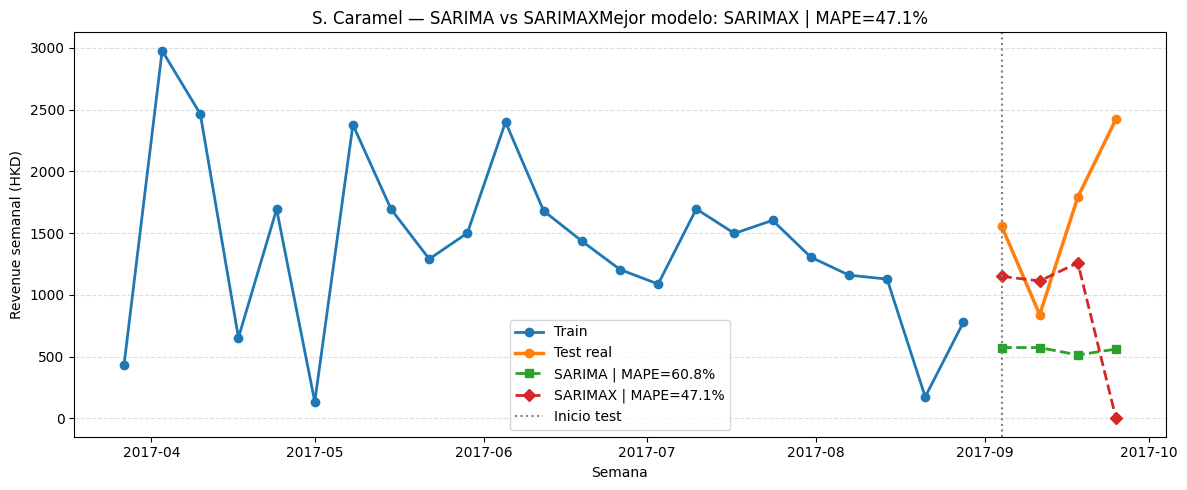

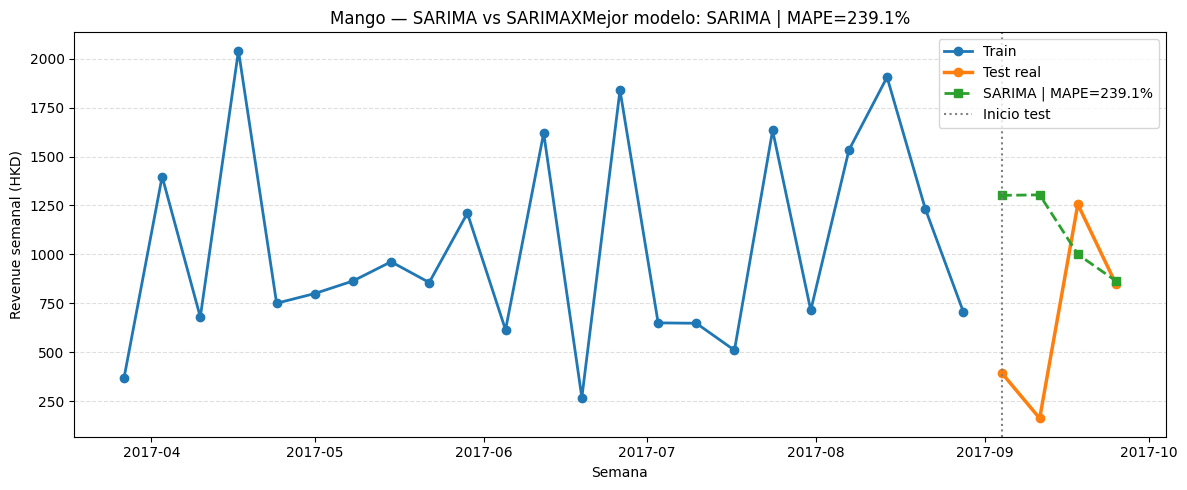

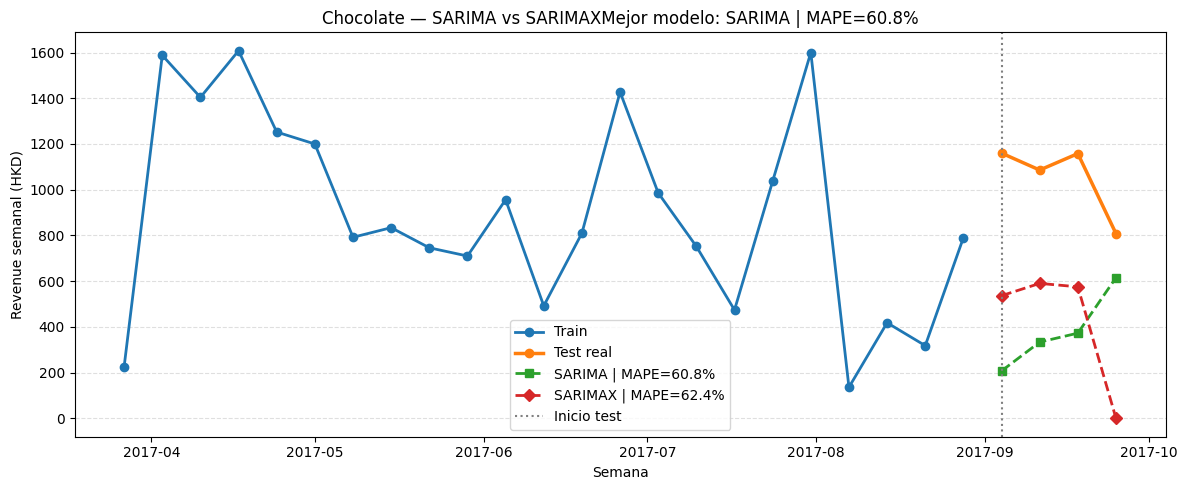

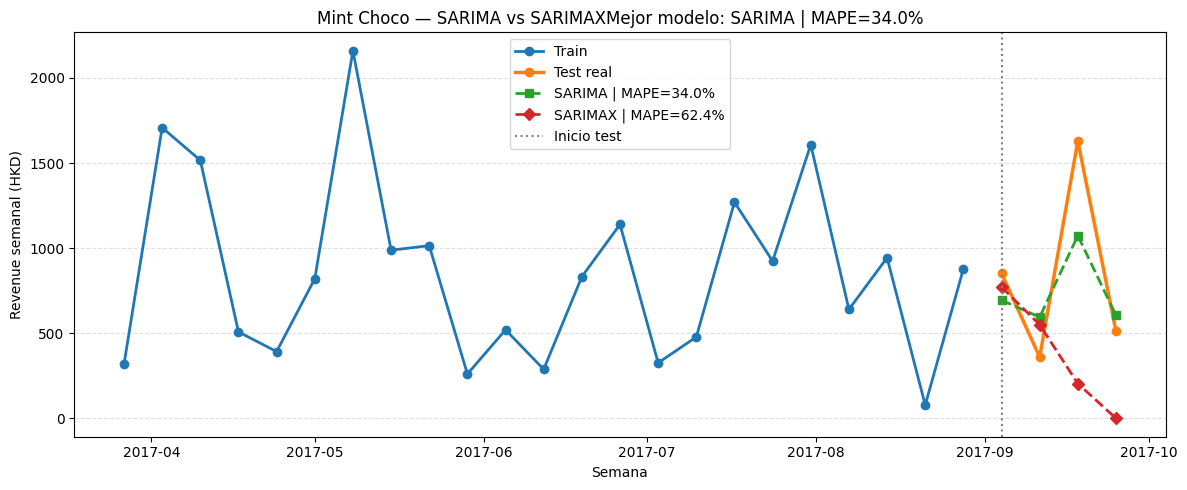

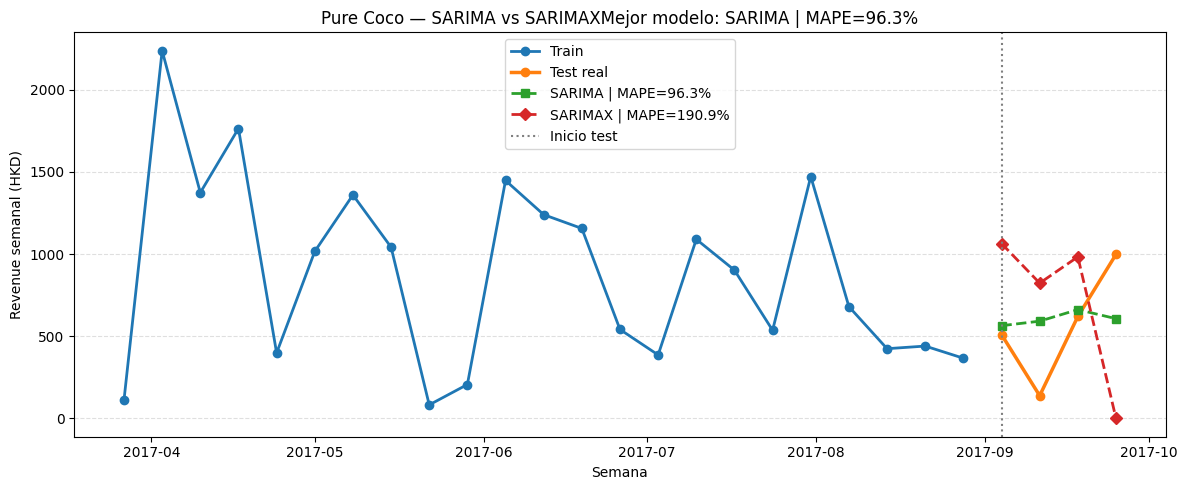

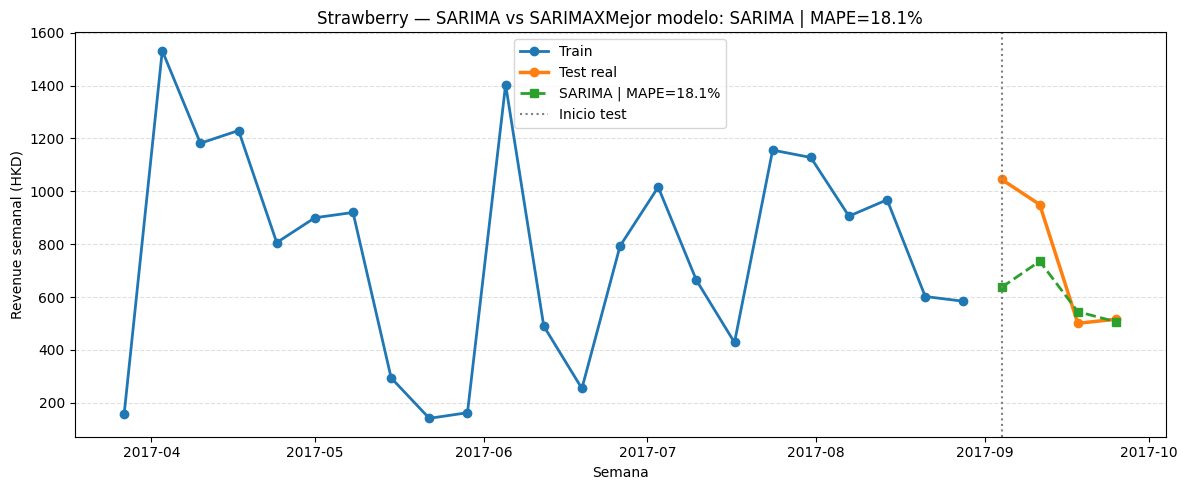

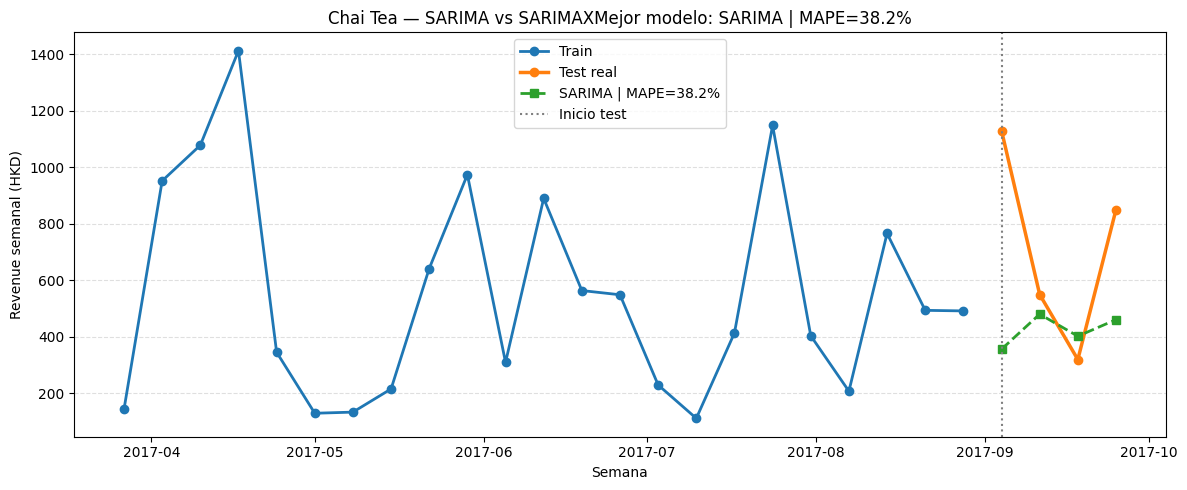

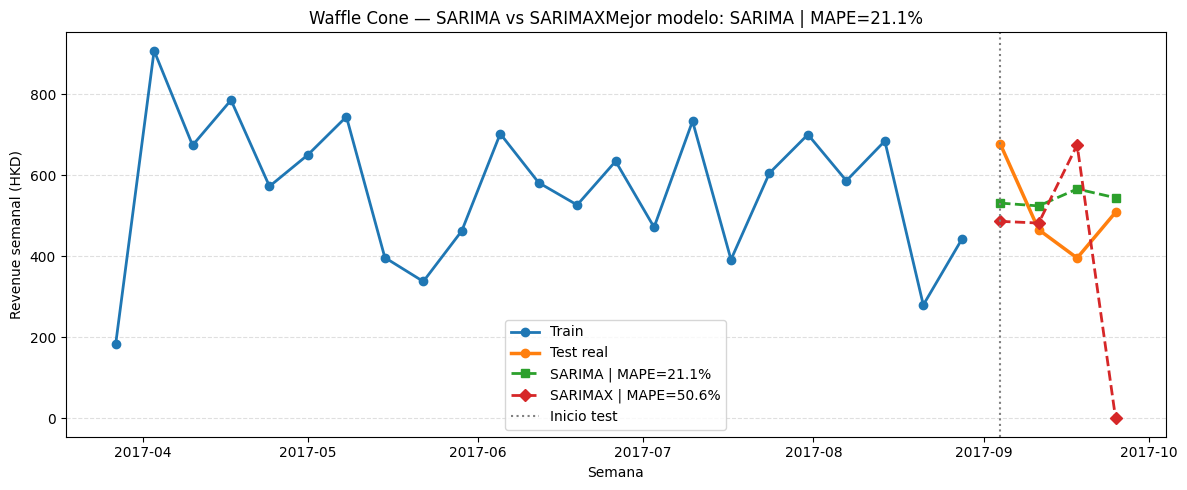

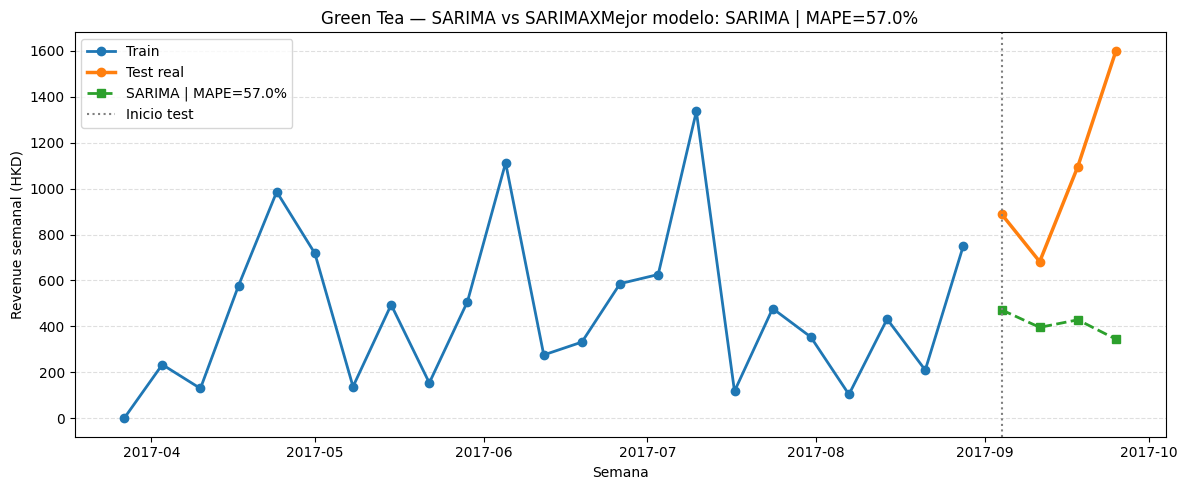

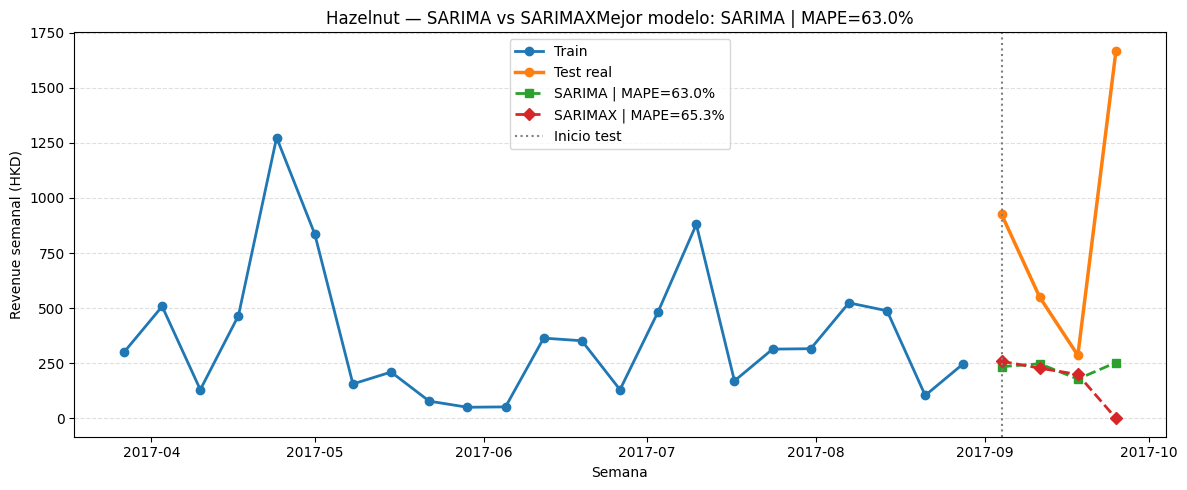

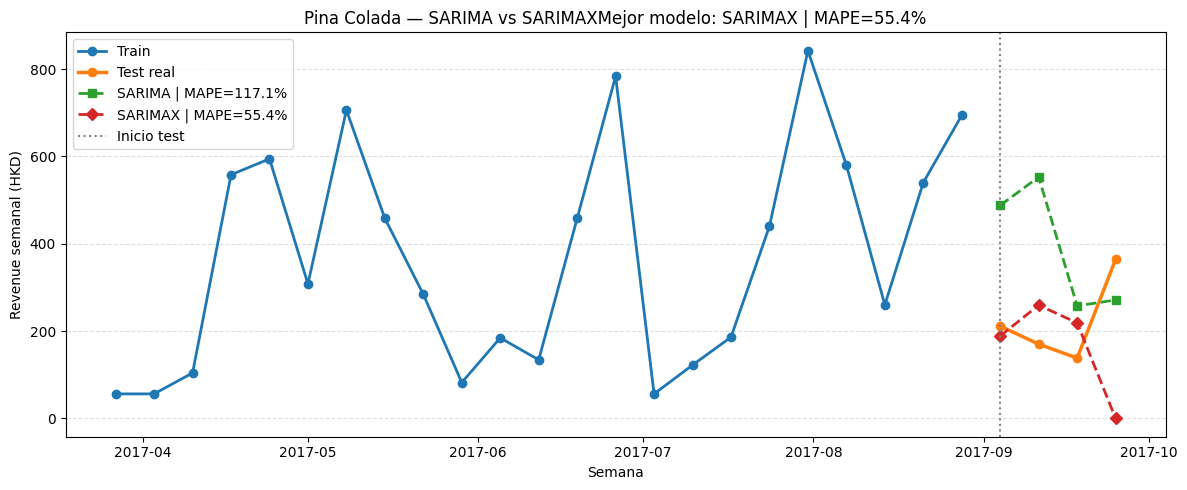

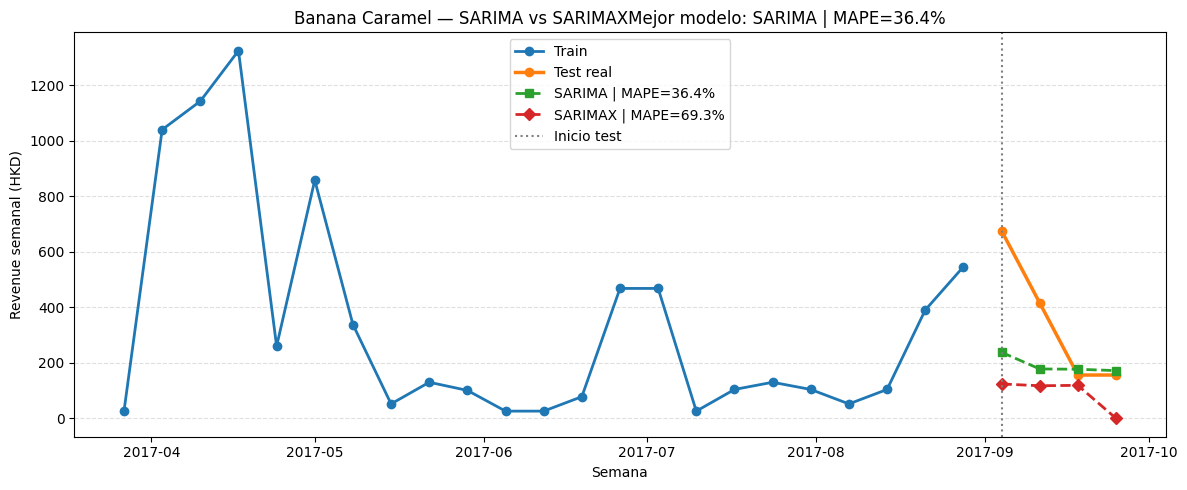

In [14]:
# =============================================================================
# 13. GRÁFICAS SARIMA vs SARIMAX POR PRODUCTO
# =============================================================================

for producto, d in predicciones.items():
    train = d["train"]
    test = d["test"]
    pred_sarima = d["pred_sarima"]
    pred_sarimax = d["pred_sarimax"]

    fila = df_resultados[df_resultados["Producto"] == producto].iloc[0]

    plt.figure(figsize=(12, 5))
    plt.plot(train["ds"], train["y"], marker="o", linewidth=2, label="Train")
    plt.plot(test["ds"], test["y"], marker="o", linewidth=2.5, label="Test real")

    if np.all(np.isfinite(pred_sarima)):
        plt.plot(test["ds"], pred_sarima, marker="s", linestyle="--", linewidth=2,
                 label=f"SARIMA | MAPE={fila['SARIMA_MAPE']:.1f}%")

    if np.all(np.isfinite(pred_sarimax)):
        plt.plot(test["ds"], pred_sarimax, marker="D", linestyle="--", linewidth=2,
                 label=f"SARIMAX | MAPE={fila['SARIMAX_MAPE']:.1f}%")

    plt.axvline(test["ds"].iloc[0], linestyle=":", color="gray", label="Inicio test")
    plt.title(
        f"{producto} — SARIMA vs SARIMAX"
        f"Mejor modelo: {fila['Mejor_modelo']} | MAPE={fila['Mejor_MAPE']:.1f}%"
    )
    plt.xlabel("Semana")
    plt.ylabel("Revenue semanal (HKD)")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 14–21. Modelos adicionales: ETS, Prophet y LightGBM

Se agregan tres modelos alternativos para comparar contra SARIMA/SARIMAX:

- **ETS (Holt-Winters)**: suavizado exponencial triple con componente estacional aditivo/multiplicativo. Muy efectivo para series cortas.
- **Prophet**: modelo de Meta que descompone la serie en tendencia + estacionalidad. Maneja automáticamente la estacionalidad semanal.
- **LightGBM con lags**: enfoque ML que construye features de lag (1–4 semanas) + variables exógenas. Captura patrones no lineales.

Todos los modelos comparten el mismo split train/test (ultimas 4 semanas como test) y las mismas métricas (MAE, RMSE, MAPE).

In [15]:
# =============================================================================
# 14. INSTALACION DE DEPENDENCIAS ADICIONALES (ejecutar una sola vez)
# =============================================================================

import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

try:
    from prophet import Prophet
    print('Prophet ya instalado.')
except ImportError:
    print('Instalando Prophet...')
    pip_install('prophet')
    from prophet import Prophet

try:
    import lightgbm as lgb
    print('LightGBM ya instalado.')
except ImportError:
    print('Instalando LightGBM...')
    pip_install('lightgbm')
    import lightgbm as lgb

from statsmodels.tsa.holtwinters import ExponentialSmoothing
print('ExponentialSmoothing (ETS) disponible desde statsmodels.')
print('\nTodas las dependencias listas.')


Instalando Prophet...


Importing plotly failed. Interactive plots will not work.


Instalando LightGBM...
ExponentialSmoothing (ETS) disponible desde statsmodels.

Todas las dependencias listas.


In [16]:
# =============================================================================
# 15. FUNCION ETS (HOLT-WINTERS EXPONENTIAL SMOOTHING)
# =============================================================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing

def entrenar_ets(y_train, horizonte=4, m=4):
    y      = np.array(y_train, dtype=float)
    y_safe = np.where(y == 0, 0.01, y)

    if len(y) >= 2 * m + 2:
        configs = [
            dict(trend='add', damped_trend=False, seasonal='add', seasonal_periods=m),
            dict(trend='add', damped_trend=True,  seasonal='add', seasonal_periods=m),
            dict(trend='add', damped_trend=False, seasonal='mul', seasonal_periods=m),
            dict(trend='add', damped_trend=True,  seasonal='mul', seasonal_periods=m),
            dict(trend=None,  damped_trend=False, seasonal='add', seasonal_periods=m),
            dict(trend=None,  damped_trend=False, seasonal='mul', seasonal_periods=m),
        ]
    else:
        configs = [
            dict(trend='add', damped_trend=True,  seasonal=None),
            dict(trend='add', damped_trend=False, seasonal=None),
            dict(trend=None,  damped_trend=False, seasonal=None),
        ]

    mejor_aic    = np.inf
    mejor_modelo = None

    for cfg in configs:
        try:
            use_mul = cfg.get('seasonal') == 'mul'
            y_input = y_safe if use_mul else y
            mod     = ExponentialSmoothing(y_input, **cfg)
            fit     = mod.fit(optimized=True, remove_bias=True)
            if np.isfinite(fit.aic) and fit.aic < mejor_aic:
                mejor_aic    = fit.aic
                mejor_modelo = fit
        except Exception:
            continue

    if mejor_modelo is None:
        return None
    try:
        pred = mejor_modelo.forecast(horizonte)
        return np.maximum(pred, 0)
    except Exception:
        return None


In [17]:
# =============================================================================
# 16. FUNCION PROPHET
# =============================================================================

from prophet import Prophet

def entrenar_prophet(train_df, horizonte=4, columnas_exog=None):
    df_p      = train_df[['ds', 'y']].copy()
    df_p['y'] = df_p['y'].astype(float)

    m = Prophet(
        weekly_seasonality=True,
        yearly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=1.0,
        interval_width=0.80
    )

    if columnas_exog:
        for col in columnas_exog:
            m.add_regressor(col, mode='additive')
            df_p[col] = train_df[col].values

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        try:
            m.fit(df_p)
        except Exception:
            return None

    future = m.make_future_dataframe(periods=horizonte, freq='W').tail(horizonte).reset_index(drop=True)

    if columnas_exog:
        for col in columnas_exog:
            future[col] = float(train_df[col].mean())

    try:
        forecast = m.predict(future)
        return np.maximum(forecast['yhat'].values, 0)
    except Exception:
        return None


In [18]:
# =============================================================================
# 17. FUNCION LIGHTGBM CON FEATURES DE LAG
# =============================================================================

import lightgbm as lgb

def construir_features_lag(serie_df, columnas_exog=None, lags=[1, 2, 3, 4], horizonte=4):
    df_f = serie_df.copy().reset_index(drop=True)

    for lag in lags:
        df_f[f'lag_{lag}'] = df_f['y'].shift(lag)

    df_f['rolling_mean_2'] = df_f['y'].shift(1).rolling(2).mean()
    df_f['rolling_mean_4'] = df_f['y'].shift(1).rolling(4).mean()
    df_f['rolling_std_4']  = df_f['y'].shift(1).rolling(4).std().fillna(0)
    df_f['week_of_year']   = pd.to_datetime(df_f['ds']).dt.isocalendar().week.astype(int)
    df_f['month']          = pd.to_datetime(df_f['ds']).dt.month

    feat_cols = [f'lag_{l}' for l in lags] + [
        'rolling_mean_2', 'rolling_mean_4', 'rolling_std_4', 'week_of_year', 'month'
    ]
    if columnas_exog:
        feat_cols += [c for c in columnas_exog if c in df_f.columns]

    train_f = df_f.iloc[:-horizonte].dropna(subset=feat_cols)
    test_f  = df_f.iloc[-horizonte:].copy()

    for col in feat_cols:
        if col in test_f.columns:
            test_f[col] = test_f[col].fillna(train_f[col].mean())

    return train_f[feat_cols], train_f['y'].values, test_f[feat_cols], feat_cols


def entrenar_lgbm(serie_df, columnas_exog=None, lags=[1, 2, 3, 4], horizonte=4):
    X_train, y_train, X_test, _ = construir_features_lag(
        serie_df, columnas_exog=columnas_exog, lags=lags, horizonte=horizonte
    )
    if len(X_train) < 6:
        return None

    y_log  = np.log1p(y_train)
    params = dict(
        objective='regression',
        metric='rmse',
        num_leaves=8,
        learning_rate=0.05,
        n_estimators=200,
        min_child_samples=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        verbose=-1,
        random_state=42
    )
    try:
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_log)
        return np.maximum(np.expm1(model.predict(X_test)), 0)
    except Exception:
        return None


In [19]:
# =============================================================================
# 18. ENTRENAMIENTO ETS + PROPHET + LGBM POR PRODUCTO
# =============================================================================

resultados_nuevos = []

for producto in top_productos:
    print('=' * 70)
    print(f'Producto: {producto}')
    print('=' * 70)

    serie = (
        dataset_modelos[dataset_modelos['producto'] == producto]
        .sort_values('ds')
        .reset_index(drop=True)
    )

    if len(serie) <= HORIZONTE + 8:
        print('Serie muy corta. Se omite.')
        continue

    train = serie.iloc[:-HORIZONTE].copy()
    test  = serie.iloc[-HORIZONTE:].copy()

    y_train = train['y'].values.astype(float)
    y_test  = test['y'].values.astype(float)

    if y_train.sum() == 0:
        print('Sin revenue en train. Se omite.')
        continue

    # Recuperar SARIMA/SARIMAX previos
    fila_ant     = df_resultados[df_resultados['Producto'] == producto]
    mape_sarima  = fila_ant['SARIMA_MAPE'].values[0]  if len(fila_ant) else np.nan
    mape_sarimax = fila_ant['SARIMAX_MAPE'].values[0] if len(fila_ant) else np.nan
    mae_sarima   = fila_ant['SARIMA_MAE'].values[0]   if len(fila_ant) else np.nan
    mae_sarimax  = fila_ant['SARIMAX_MAE'].values[0]  if len(fila_ant) else np.nan
    rmse_sarima  = fila_ant['SARIMA_RMSE'].values[0]  if len(fila_ant) else np.nan
    rmse_sarimax = fila_ant['SARIMAX_RMSE'].values[0] if len(fila_ant) else np.nan

    # ETS
    pred_ets = entrenar_ets(y_train, horizonte=HORIZONTE, m=M)
    if pred_ets is not None and predicciones_validas(pred_ets, y_train):
        mae_ets, rmse_ets, mape_ets = calcular_metricas(y_test, pred_ets)
    else:
        pred_ets = np.full(HORIZONTE, np.nan)
        mae_ets = rmse_ets = mape_ets = np.nan
    print(f'ETS     -> MAE: {mae_ets:.0f} | RMSE: {rmse_ets:.0f} | MAPE: {mape_ets:.1f}%')

    # Prophet
    exog_validas = [c for c in columnas_exogenas if train[c].std() > 0]
    pred_prophet = entrenar_prophet(train, horizonte=HORIZONTE, columnas_exog=exog_validas)
    if pred_prophet is not None and predicciones_validas(pred_prophet, y_train):
        mae_prophet, rmse_prophet, mape_prophet = calcular_metricas(y_test, pred_prophet)
    else:
        pred_prophet = np.full(HORIZONTE, np.nan)
        mae_prophet = rmse_prophet = mape_prophet = np.nan
    print(f'Prophet -> MAE: {mae_prophet:.0f} | RMSE: {rmse_prophet:.0f} | MAPE: {mape_prophet:.1f}%')

    # LightGBM
    pred_lgbm = entrenar_lgbm(serie, columnas_exog=columnas_exogenas, horizonte=HORIZONTE)
    if pred_lgbm is not None and predicciones_validas(pred_lgbm, y_train):
        mae_lgbm, rmse_lgbm, mape_lgbm = calcular_metricas(y_test, pred_lgbm)
    else:
        pred_lgbm = np.full(HORIZONTE, np.nan)
        mae_lgbm = rmse_lgbm = mape_lgbm = np.nan
    print(f'LGBM    -> MAE: {mae_lgbm:.0f} | RMSE: {rmse_lgbm:.0f} | MAPE: {mape_lgbm:.1f}%')

    # Guardar predicciones adicionales
    predicciones[producto]['pred_ets']     = pred_ets
    predicciones[producto]['pred_prophet'] = pred_prophet
    predicciones[producto]['pred_lgbm']    = pred_lgbm

    # Mejor de los 5
    candidatos = {
        'SARIMA':   mape_sarima,
        'SARIMAX':  mape_sarimax,
        'ETS':      mape_ets,
        'Prophet':  mape_prophet,
        'LightGBM': mape_lgbm
    }
    validos = {k: v for k, v in candidatos.items() if np.isfinite(v)}
    if validos:
        mejor_global      = min(validos, key=validos.get)
        mejor_mape_global = validos[mejor_global]
    else:
        mejor_global      = 'Sin modelo estable'
        mejor_mape_global = np.nan

    print(f'>>> Mejor global: {mejor_global} | MAPE={mejor_mape_global:.1f}%')

    resultados_nuevos.append({
        'Producto':          producto,
        'ETS_MAE':           mae_ets,
        'ETS_RMSE':          rmse_ets,
        'ETS_MAPE':          mape_ets,
        'Prophet_MAE':       mae_prophet,
        'Prophet_RMSE':      rmse_prophet,
        'Prophet_MAPE':      mape_prophet,
        'LightGBM_MAE':      mae_lgbm,
        'LightGBM_RMSE':     rmse_lgbm,
        'LightGBM_MAPE':     mape_lgbm,
        'Mejor_global':      mejor_global,
        'Mejor_MAPE_global': mejor_mape_global
    })

df_nuevos = pd.DataFrame(resultados_nuevos)
df_nuevos


Producto: S. Caramel


21:03:09 - cmdstanpy - INFO - Chain [1] start processing


ETS     -> MAE: 824 | RMSE: 945 | MAPE: 44.6%


21:03:09 - cmdstanpy - INFO - Chain [1] done processing


Prophet -> MAE: 1447 | RMSE: 1574 | MAPE: 84.4%
LGBM    -> MAE: nan | RMSE: nan | MAPE: nan%
>>> Mejor global: ETS | MAPE=44.6%
Producto: Mango


...

21:03:33 - cmdstanpy - INFO - Chain [1] start processing
21:03:33 - cmdstanpy - INFO - Chain [1] done processing


ETS     -> MAE: 148 | RMSE: 159 | MAPE: 85.2%
Prophet -> MAE: 582 | RMSE: 587 | MAPE: 311.9%
LGBM    -> MAE: nan | RMSE: nan | MAPE: nan%
>>> Mejor global: SARIMAX | MAPE=55.4%
Producto: Banana Caramel


21:03:36 - cmdstanpy - INFO - Chain [1] start processing
21:03:36 - cmdstanpy - INFO - Chain [1] done processing


ETS     -> MAE: 285 | RMSE: 287 | MAPE: 119.0%
Prophet -> MAE: 351 | RMSE: 412 | MAPE: 100.0%
LGBM    -> MAE: nan | RMSE: nan | MAPE: nan%
>>> Mejor global: SARIMA | MAPE=36.4%


,Producto,ETS_MAE,ETS_RMSE,ETS_MAPE,Prophet_MAE,Prophet_RMSE,Prophet_MAPE,LightGBM_MAE,LightGBM_RMSE,LightGBM_MAPE,Mejor_global,Mejor_MAPE_global
0,S. Caramel,823.592787,944.937417,44.591923,1446.528244,1573.768174,84.399425,NaN,NaN,NaN,ETS,44.591923
1,Mango,454.988951,578.708890,162.002141,469.801520,544.938286,180.183807,NaN,NaN,NaN,ETS,162.002141
2,Chocolate,545.291406,610.518404,49.317703,808.785890,817.138830,76.774535,NaN,NaN,NaN,ETS,49.317703
3,Mint Choco,542.626684,580.055873,82.615008,404.014113,492.074000,58.616750,NaN,NaN,NaN,SARIMA,33.962157
4,Pure Coco,246.571917,348.517913,35.611102,374.588664,451.890401,70.104494,NaN,NaN,NaN,ETS,35.611102
5,Strawberry,424.857474,433.004635,63.940163,246.152638,263.300918,32.295382,NaN,NaN,NaN,SARIMA,18.083944
6,Chai Tea,357.379047,399.578888,57.973329,712.500000,775.290268,100.000000,NaN,NaN,NaN,SARIMA,38.159242
7,Waffle Cone,96.383008,117.003453,20.990692,110.546553,146.927389,18.819842,NaN,NaN,NaN,Prophet,18.819842
8,Green Tea,599.516634,672.333862,53.466052,586.461756,675.852917,50.562617,NaN,NaN,NaN,Prophet,50.562617
9,Hazelnut,504.547035,753.123706,41.470141,546.115912,735.339116,50.085207,NaN,NaN,NaN,ETS,41.470141


In [20]:
# =============================================================================
# 19. TABLA COMPARATIVA FINAL — 5 MODELOS
# =============================================================================

df_completo = df_resultados.merge(df_nuevos, on='Producto', how='outer')

cols_display = [
    'Producto',
    'SARIMA_MAPE', 'SARIMAX_MAPE',
    'ETS_MAPE', 'Prophet_MAPE', 'LightGBM_MAPE',
    'Mejor_global', 'Mejor_MAPE_global'
]

df_final = df_completo[cols_display].sort_values('Mejor_MAPE_global').copy()
for c in [col for col in cols_display if 'MAPE' in col]:
    df_final[c] = df_final[c].apply(lambda x: f'{x:.1f}%' if np.isfinite(x) else 'N/A')

print('Comparacion final de todos los modelos (ordenado por mejor MAPE global):')
df_final


Comparacion final de todos los modelos (ordenado por mejor MAPE global):


,Producto,SARIMA_MAPE,SARIMAX_MAPE,ETS_MAPE,Prophet_MAPE,LightGBM_MAPE,Mejor_global,Mejor_MAPE_global
10,Strawberry,18.1%,N/A,63.9%,32.3%,N/A,SARIMA,18.1%
11,Waffle Cone,21.1%,50.6%,21.0%,18.8%,N/A,Prophet,18.8%
6,Mint Choco,34.0%,62.4%,82.6%,58.6%,N/A,SARIMA,34.0%
8,Pure Coco,96.3%,190.9%,35.6%,70.1%,N/A,ETS,35.6%
0,Banana Caramel,36.4%,69.3%,119.0%,100.0%,N/A,SARIMA,36.4%
1,Chai Tea,38.2%,N/A,58.0%,100.0%,N/A,SARIMA,38.2%
4,Hazelnut,63.0%,65.3%,41.5%,50.1%,N/A,ETS,41.5%
9,S. Caramel,60.8%,47.1%,44.6%,84.4%,N/A,ETS,44.6%
2,Chocolate,60.8%,62.4%,49.3%,76.8%,N/A,ETS,49.3%
3,Green Tea,57.0%,N/A,53.5%,50.6%,N/A,Prophet,50.6%


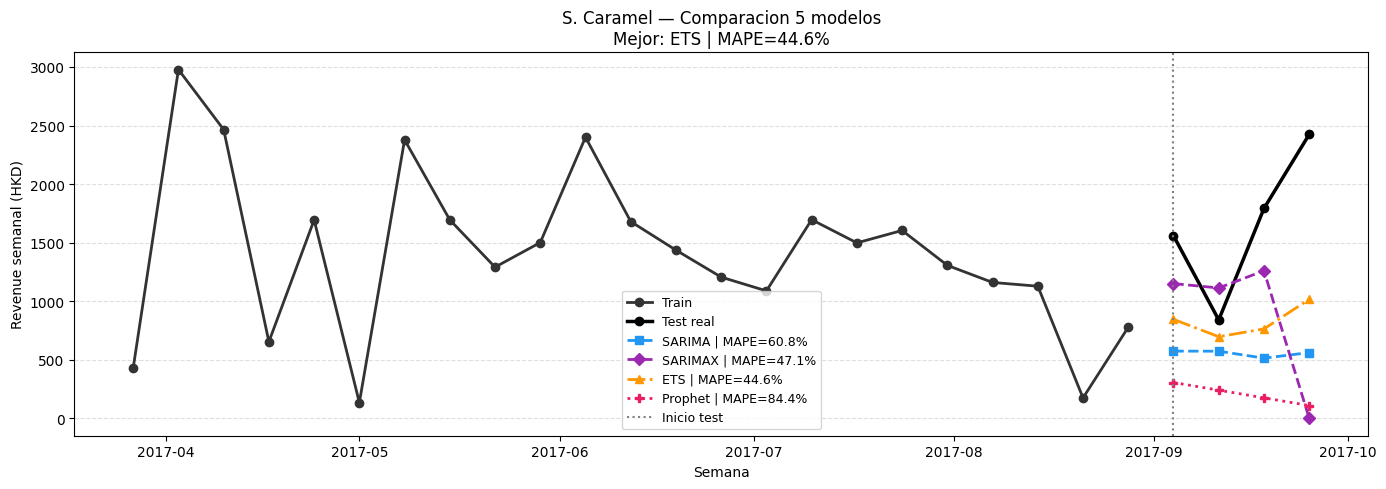

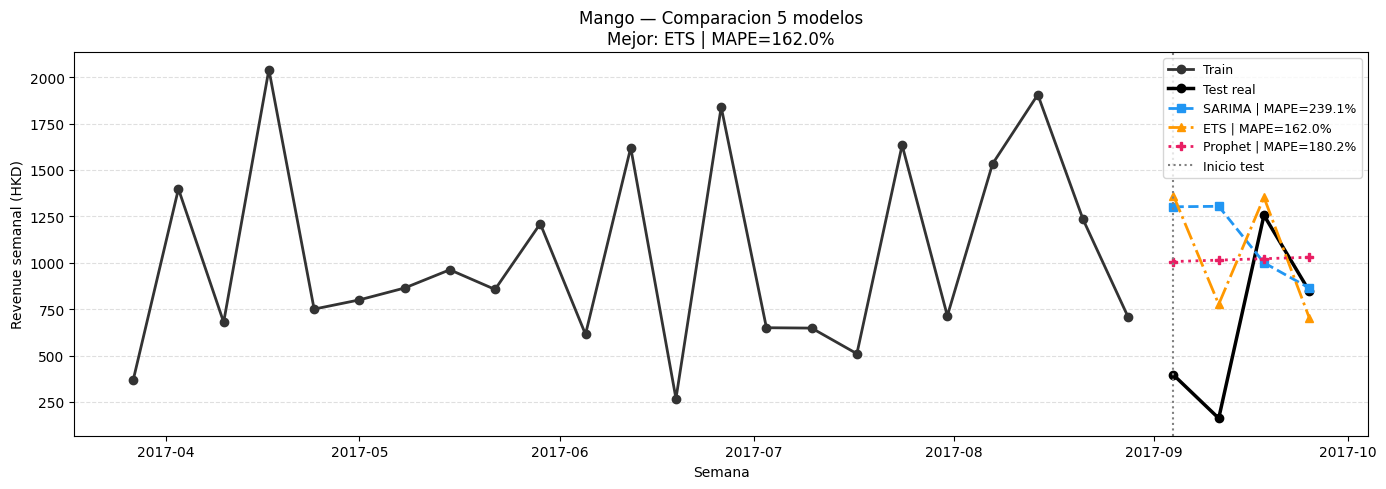

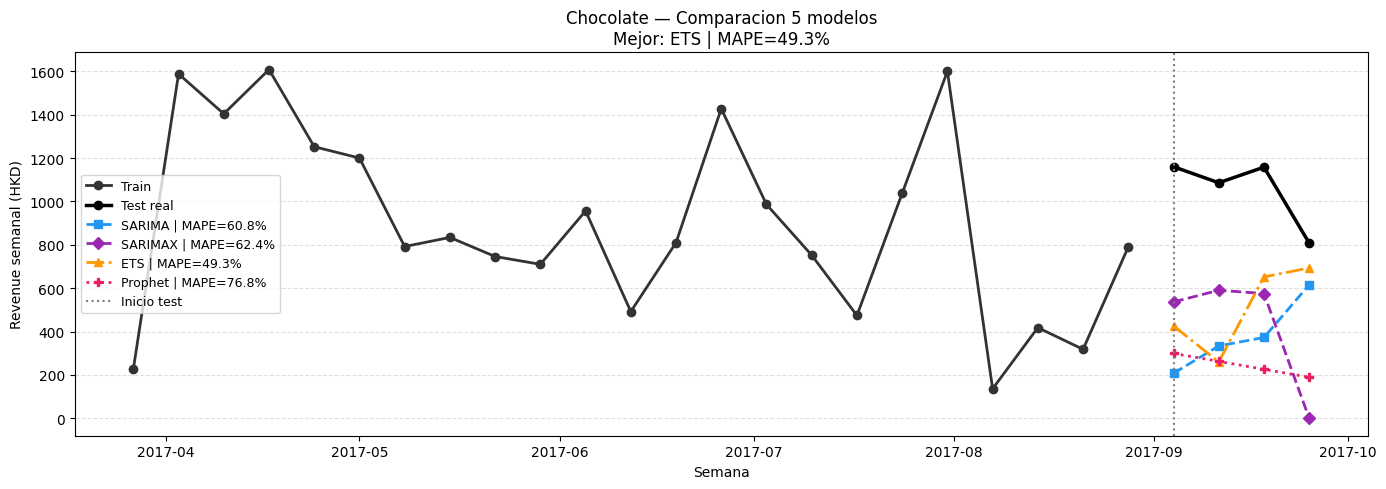

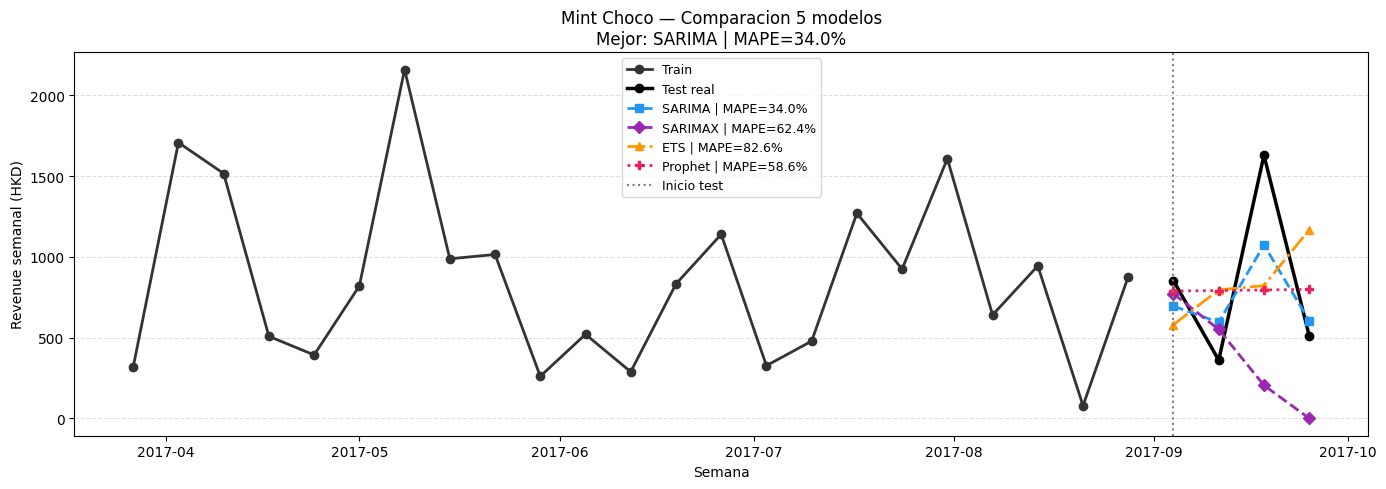

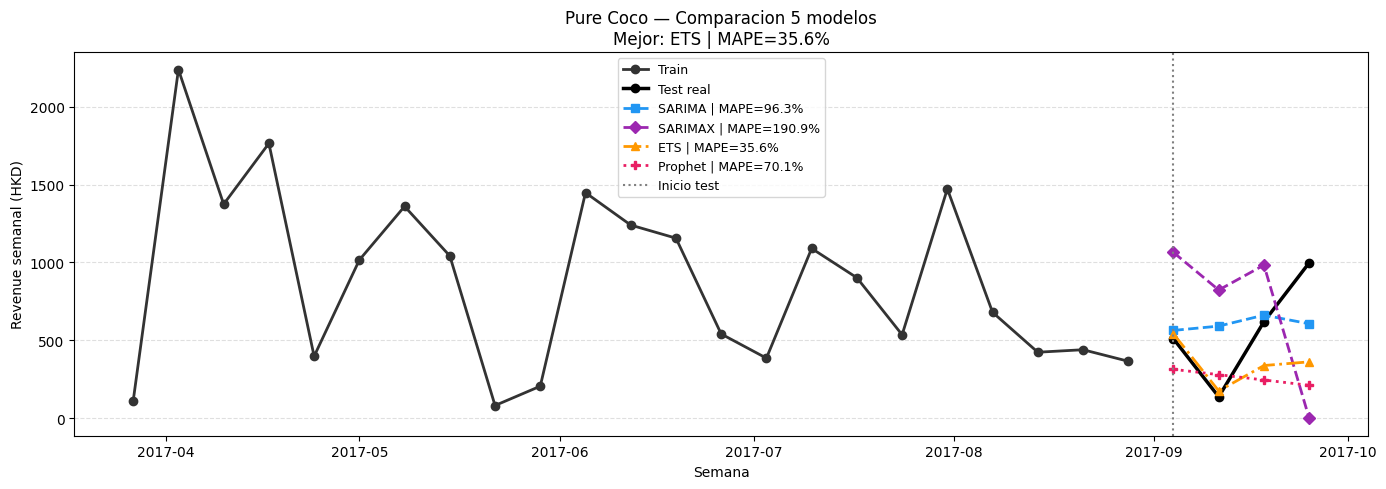

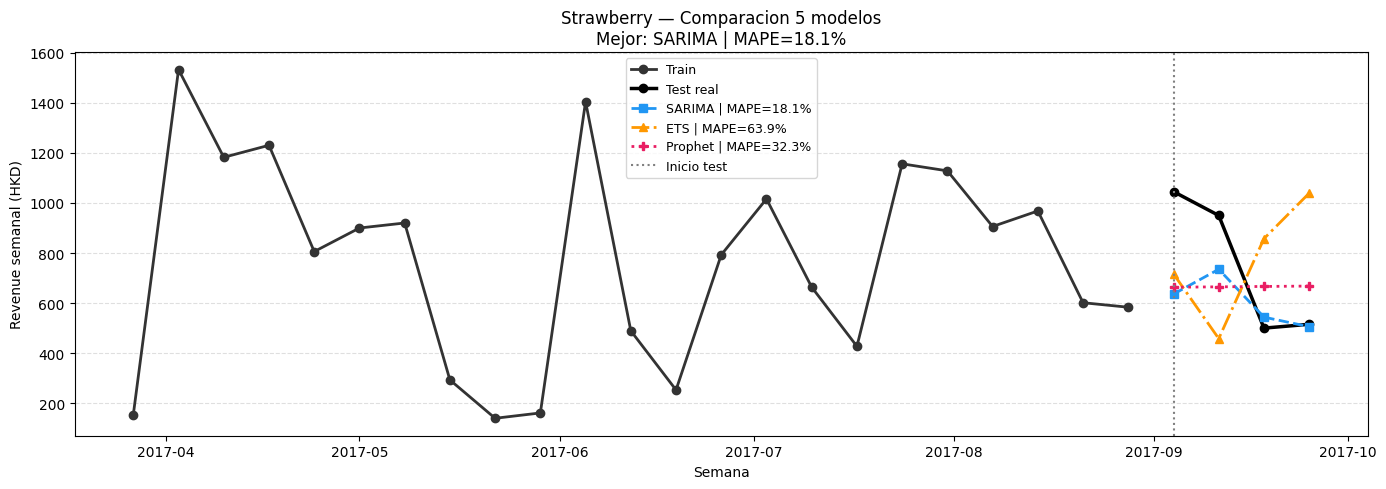

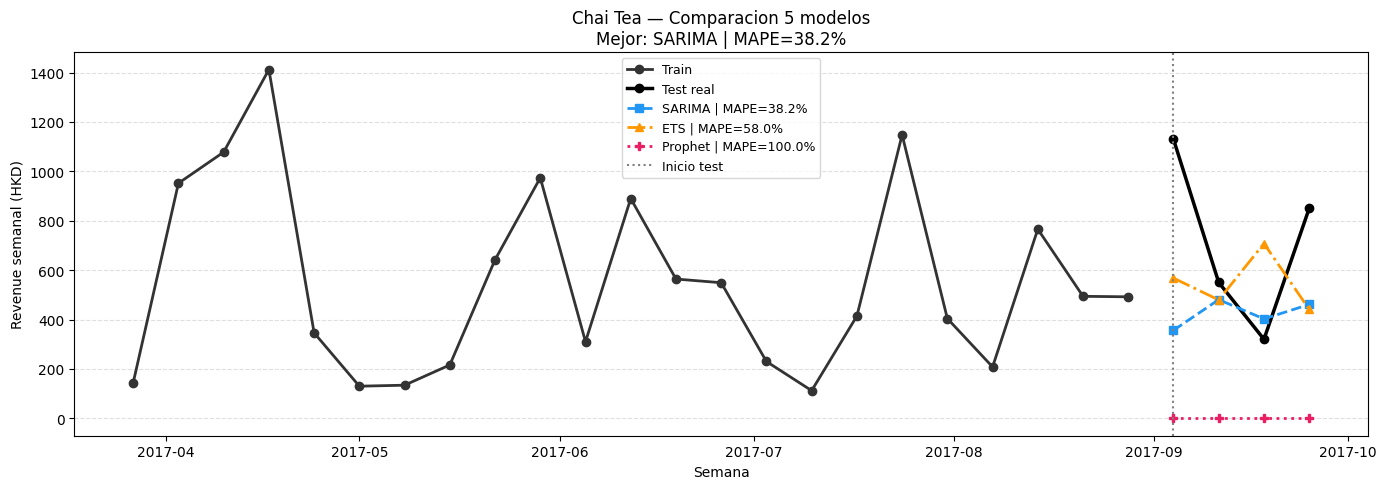

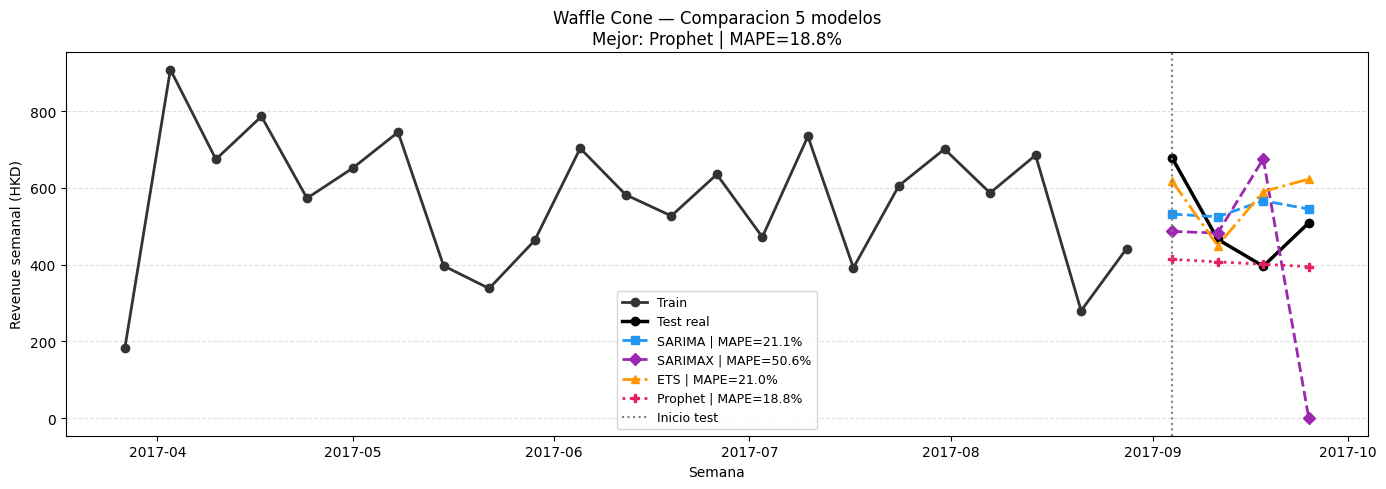

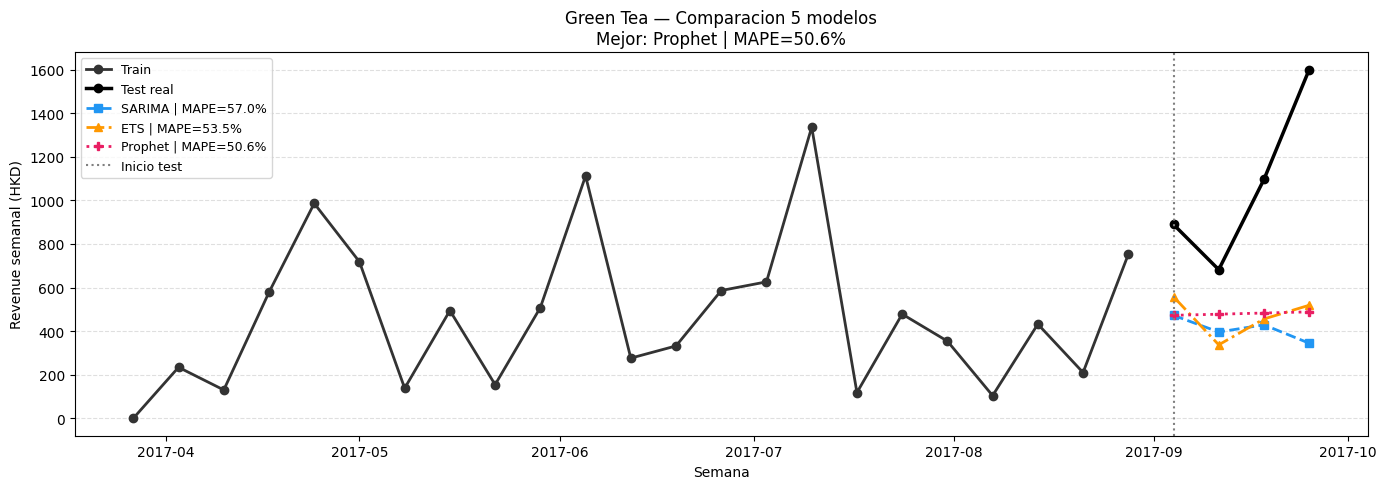

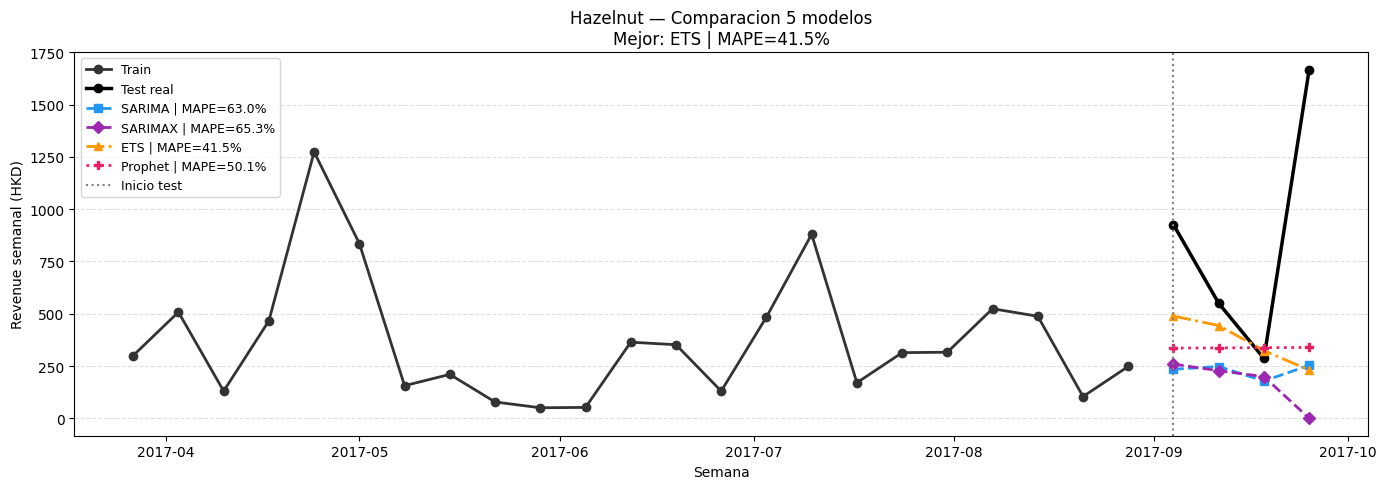

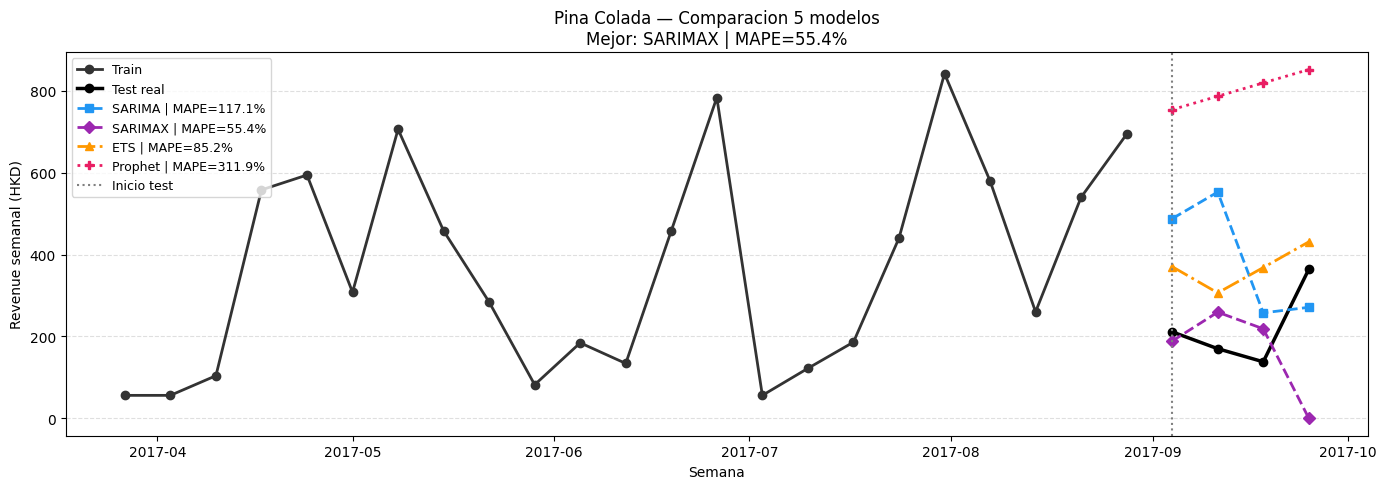

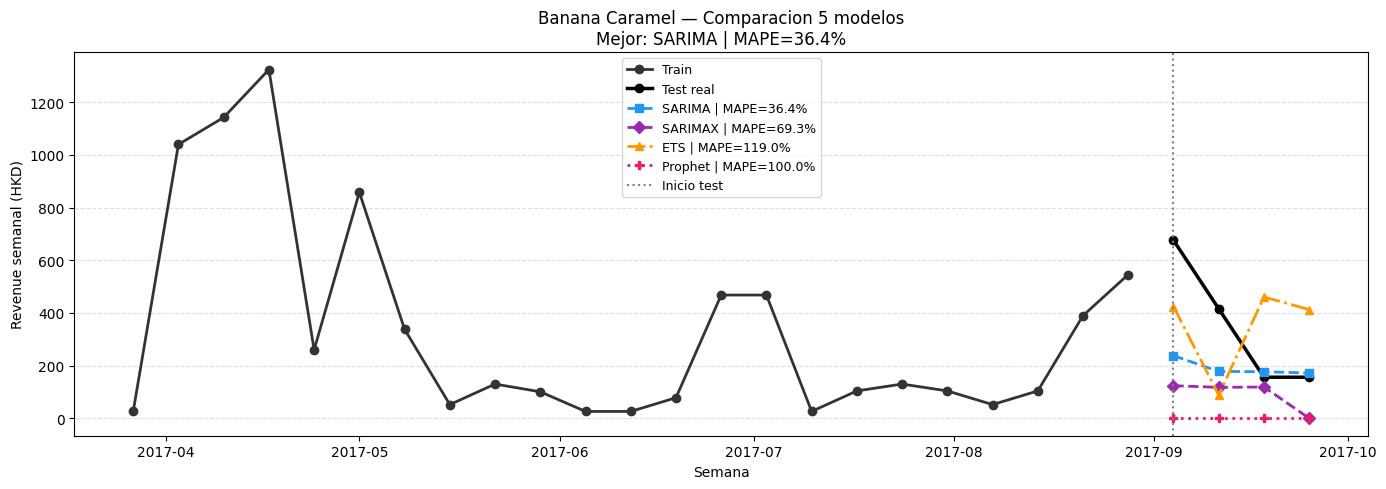

In [21]:
# =============================================================================
# 20. GRAFICAS COMPARATIVAS — 5 MODELOS
# =============================================================================

estilos = {
    'pred_sarima':  dict(color='#2196F3', marker='s', ls='--',  label='SARIMA',    mape_col='SARIMA_MAPE'),
    'pred_sarimax': dict(color='#9C27B0', marker='D', ls='--',  label='SARIMAX',   mape_col='SARIMAX_MAPE'),
    'pred_ets':     dict(color='#FF9800', marker='^', ls='-.',  label='ETS',       mape_col='ETS_MAPE'),
    'pred_prophet': dict(color='#E91E63', marker='P', ls=':',   label='Prophet',   mape_col='Prophet_MAPE'),
    'pred_lgbm':    dict(color='#4CAF50', marker='*', ls='-',   label='LightGBM',  mape_col='LightGBM_MAPE'),
}

for producto, d in predicciones.items():
    train = d['train']
    test  = d['test']

    fila = df_completo[df_completo['Producto'] == producto]
    if len(fila) == 0:
        continue
    fila = fila.iloc[0]

    plt.figure(figsize=(14, 5))
    plt.plot(train['ds'], train['y'], marker='o', lw=2, color='#333333', label='Train')
    plt.plot(test['ds'],  test['y'],  marker='o', lw=2.5, color='#000000', label='Test real')

    for key, cfg in estilos.items():
        pred = d.get(key)
        if pred is None or not np.all(np.isfinite(pred)):
            continue
        mape_v = fila.get(cfg['mape_col'], np.nan)
        lbl    = cfg['label'] + (f" | MAPE={mape_v:.1f}%" if np.isfinite(mape_v) else '')
        plt.plot(test['ds'], pred,
                 marker=cfg['marker'], linestyle=cfg['ls'], lw=2,
                 color=cfg['color'], label=lbl)

    plt.axvline(test['ds'].iloc[0], linestyle=':', color='gray', label='Inicio test')

    mejor  = fila.get('Mejor_global', '?')
    mape_g = fila.get('Mejor_MAPE_global', np.nan)
    titulo_m = f'{mape_g:.1f}%' if np.isfinite(mape_g) else 'N/A'
    plt.title(f'{producto} — Comparacion 5 modelos\nMejor: {mejor} | MAPE={titulo_m}')
    plt.xlabel('Semana')
    plt.ylabel('Revenue semanal (HKD)')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


In [23]:
# =============================================================================
# 21. RESUMEN DE GANADORES Y MEJORA vs BASELINE SARIMA
# =============================================================================

print('=' * 65)
print('RESUMEN DE GANADORES POR PRODUCTO')
print('=' * 65)

for _, row in df_completo.iterrows():
    prod    = row['Producto']
    ganador = row.get('Mejor_global', '?')
    mape_g  = row.get('Mejor_MAPE_global', np.nan)
    mape_s  = row.get('SARIMA_MAPE', np.nan)
    # SARIMAX_MAPE
    mape_sx = row.get('SARIMAX_MAPE', np.nan)

    if np.isfinite(mape_sx) and np.isfinite(mape_g) and mape_sx > 0:
        mejora = (mape_sx - mape_g) / mape_sx * 100
        extra  = f'  (mejora vs SARIMAX: {mejora:+.1f}%)'
    else:
        extra  = ''

    print(f'  {prod:<28} -> {ganador:<10} | MAPE={mape_g:.1f}%{extra}')

print()
print('Distribucion de ganadores:')
print(df_completo['Mejor_global'].value_counts().to_string())


RESUMEN DE GANADORES POR PRODUCTO
  Banana Caramel               -> SARIMA     | MAPE=36.4%  (mejora vs SARIMAX: +47.5%)
  Chai Tea                     -> SARIMA     | MAPE=38.2%
  Chocolate                    -> ETS        | MAPE=49.3%  (mejora vs SARIMAX: +21.0%)
  Green Tea                    -> Prophet    | MAPE=50.6%
  Hazelnut                     -> ETS        | MAPE=41.5%  (mejora vs SARIMAX: +36.4%)
  Mango                        -> ETS        | MAPE=162.0%
  Mint Choco                   -> SARIMA     | MAPE=34.0%  (mejora vs SARIMAX: +45.6%)
  Pina Colada                  -> SARIMAX    | MAPE=55.4%  (mejora vs SARIMAX: +0.0%)
  Pure Coco                    -> ETS        | MAPE=35.6%  (mejora vs SARIMAX: +81.3%)
  S. Caramel                   -> ETS        | MAPE=44.6%  (mejora vs SARIMAX: +5.3%)
  Strawberry                   -> SARIMA     | MAPE=18.1%
  Waffle Cone                  -> Prophet    | MAPE=18.8%  (mejora vs SARIMAX: +62.8%)

Distribucion de ganadores:
Mejor_globa